# Task 3 – SMS Spam Detection using Natural Language Processing

## 1. Dataset Loading and Exploration

This project focuses on detecting whether an SMS message is spam or legitimate (ham) using Natural Language Processing techniques.

The project will compare a traditional TF-IDF based machine learning model with an advanced Transformer-based model.

In [1]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nFiles and folders here:")
print(os.listdir())

Current working directory:
c:\Users\user\Downloads\Internship\SPAM_DETECTION\notebook

Files and folders here:
['01_spam_detection.ipynb']


In [2]:
import pandas as pd

df = pd.read_csv(
    "../data/spam.csv",
    encoding="latin-1"
)

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
df.shape

(5572, 5)

In [4]:
print(df.columns)

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')


In [5]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")

Libraries imported successfully.


In [7]:
df = df[["v1", "v2"]]


In [8]:
df.columns = ["label", "message"]

In [9]:
df.head()


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [10]:
print("Dataset shape:", df.shape)

Dataset shape: (5572, 2)


In [11]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
label      0
message    0
dtype: int64


In [12]:
print("\nDuplicate rows:", df.duplicated().sum())


Duplicate rows: 403


In [13]:
print("\nClass distribution:")
print(df["label"].value_counts())


Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [15]:
df = df.drop_duplicates().reset_index(drop=True)

print("Dataset shape after removing duplicates:", df.shape)
print("\nDuplicates remaining:", df.duplicated().sum())

Dataset shape after removing duplicates: (5169, 2)

Duplicates remaining: 0


In [16]:
df["label_encoded"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

df.head()

,label,message,label_encoded
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [17]:
print(df["label_encoded"].value_counts())

label_encoded
0    4516
1     653
Name: count, dtype: int64


In [18]:
from sklearn.model_selection import train_test_split

# Features and target
X = df["message"]
y = df["label_encoded"]

# First split: 70% training, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# 15% validation and 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (3618,)
Validation set: (775,)
Test set: (776,)


In [19]:
print("Training distribution:")
print(y_train.value_counts())

print("\nValidation distribution:")
print(y_val.value_counts())

print("\nTest distribution:")
print(y_test.value_counts())

Training distribution:
label_encoded
0    3161
1     457
Name: count, dtype: int64

Validation distribution:
label_encoded
0    677
1     98
Name: count, dtype: int64

Test distribution:
label_encoded
0    678
1     98
Name: count, dtype: int64


In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True,
    max_features=10000
)

# Learn vocabulary and IDF from training data only
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform validation and test data using the same vocabulary
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Validation TF-IDF shape:", X_val_tfidf.shape)
print("Test TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (3618, 8863)
Validation TF-IDF shape: (775, 8863)
Test TF-IDF shape: (776, 8863)


In [21]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

baseline_model.fit(X_train_tfidf, y_train)

print("Baseline model trained successfully!")

Baseline model trained successfully!


In [22]:
y_val_pred = baseline_model.predict(X_val_tfidf)
y_test_pred = baseline_model.predict(X_test_tfidf)

In [23]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Baseline Validation Performance")
print("--------------------------------")

print("Accuracy :", accuracy_score(y_val, y_val_pred))
print("Precision:", precision_score(y_val, y_val_pred))
print("Recall   :", recall_score(y_val, y_val_pred))
print("F1 Score :", f1_score(y_val, y_val_pred))

print("\nClassification Report:")
print(classification_report(
    y_val,
    y_val_pred,
    target_names=["Ham", "Spam"]
))

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))

Baseline Validation Performance
--------------------------------
Accuracy : 0.9548387096774194
Precision: 0.9846153846153847
Recall   : 0.6530612244897959
F1 Score : 0.7852760736196319

Classification Report:
              precision    recall  f1-score   support

         Ham       0.95      1.00      0.97       677
        Spam       0.98      0.65      0.79        98

    accuracy                           0.95       775
   macro avg       0.97      0.83      0.88       775
weighted avg       0.96      0.95      0.95       775

Confusion Matrix:
[[676   1]
 [ 34  64]]


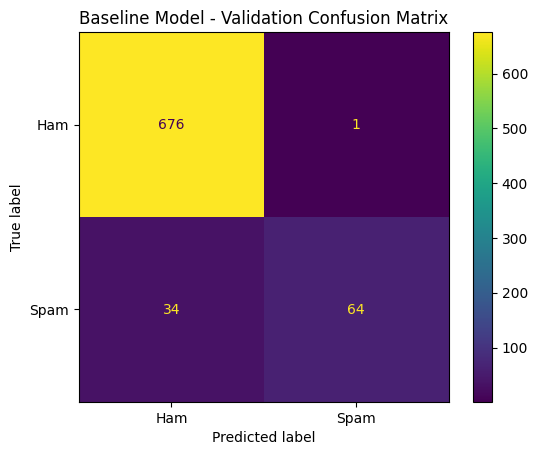

In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_val_pred,
    display_labels=["Ham", "Spam"]
)

plt.title("Baseline Model - Validation Confusion Matrix")
plt.show()

## Baseline NLP Model TF-IDF + Logistic Regression

A TF-IDF vectorizer was used to convert the SMS messages into numerical features, Unigrams and bigrams were included to capture both individual words and short phrases. The TF-IDF vectorizer was fitted only on the training data to prevent data leakage.

A Logistic Regression classifier was then trained using the TF-IDF features.

### Validation Results

| Metric | Score |
|---|---:|
| Accuracy | 0.9548 |
| Precision | 0.9846 |
| Recall | 0.6531 |
| F1 Score | 0.7853 |

The baseline achieved high precision, meaning that messages predicted as spam were usually genuinely spam. However, recall was lower at 65.31%, meaning that the model failed to detect 34 of the 98 spam messages in the validation set.
The main weakness of the baseline is therefore missed spam messages (false negatives). This provides a useful benchmark for evaluating the advanced NLP model.

### Confusion Matrix
The model produced 676 true negatives, 1 false positive, 34 false negatives, 
and 64 true positives on the validation set.

In [25]:
import re

def clean_text(text):
    # Convert to lowercase
    text = text.lower()
    
    # Remove HTML tags if present
    text = re.sub(r"<.*?>", " ", text)
    
    # Replace multiple whitespace characters with a single space
    text = re.sub(r"\s+", " ", text)
    
    # Remove leading/trailing whitespace
    text = text.strip()
    
    return text

In [26]:
df["clean_message"] = df["message"].apply(clean_text)

df[["message", "clean_message"]].head(10)

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...","go until jurong point, crazy.. available only ..."
1,Ok lar... Joking wif u oni...,ok lar... joking wif u oni...
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...
3,U dun say so early hor... U c already then say...,u dun say so early hor... u c already then say...
4,"Nah I don't think he goes to usf, he lives aro...","nah i don't think he goes to usf, he lives aro..."
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey there darling it's been 3 week's n...
6,Even my brother is not like to speak with me. ...,even my brother is not like to speak with me. ...
7,As per your request 'Melle Melle (Oru Minnamin...,as per your request 'melle melle (oru minnamin...
8,WINNER!! As a valued network customer you have...,winner!! as a valued network customer you have...
9,Had your mobile 11 months or more? U R entitle...,had your mobile 11 months or more? u r entitle...


In [27]:
print("Missing cleaned messages:", df["clean_message"].isnull().sum())

print(
    "Empty cleaned messages:",
    (df["clean_message"].str.strip() == "").sum()
)

Missing cleaned messages: 0
Empty cleaned messages: 0


In [28]:
df[df["label"] == "spam"][["message", "clean_message"]].head(10)

,message,clean_message
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey there darling it's been 3 week's n...
8,WINNER!! As a valued network customer you have...,winner!! as a valued network customer you have...
9,Had your mobile 11 months or more? U R entitle...,had your mobile 11 months or more? u r entitle...
11,"SIX chances to win CASH! From 100 to 20,000 po...","six chances to win cash! from 100 to 20,000 po..."
12,URGENT! You have won a 1 week FREE membership ...,urgent! you have won a 1 week free membership ...
15,"XXXMobileMovieClub: To use your credit, click ...","xxxmobilemovieclub: to use your credit, click ..."
19,England v Macedonia - dont miss the goals/team...,england v macedonia - dont miss the goals/team...
34,Thanks for your subscription to Ringtone UK yo...,thanks for your subscription to ringtone uk yo...
42,07732584351 - Rodger Burns - MSG = We tried to...,07732584351 - rodger burns - msg = we tried to...


In [29]:
import transformers
import datasets
import torch

print("Transformers version:", transformers.__version__)
print("Datasets version:", datasets.__version__)
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


OSError: [WinError 126] The specified module could not be found. Error loading "c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\lib\shm.dll" or one of its dependencies.